# Pipeline 3: Social Media Donation Predictor

## 1. Problem Framing

**Business question:** Which post characteristics drive donation referrals, 
and can we predict which types of posts will generate the most donor conversions?

**Who cares:** The Executive Director and anyone managing social media. The case 
explicitly states the founders "are not experienced with social media" and don't 
know "what kind of content actually leads to donations versus just generating likes." 
This pipeline directly answers that question with data.

**Two modeling goals — we do both:**

**Explanatory model:** OLS Linear Regression to identify which post 
characteristics (platform, type, topic, timing) are statistically associated 
with more donation referrals. Coefficients give the org actionable posting 
guidelines — "ImpactStory posts on Facebook on Tuesday evenings generate 
X more referrals on average."

**Predictive model:** Random Forest Regressor to predict the estimated donation 
value a post will generate before it is published. Staff can use this as a 
pre-publish scoring tool.

**Why prediction matters here over explanation alone:** The org needs both. 
The explanatory model tells them what strategy to adopt. The predictive model 
lets them score a draft post before publishing and decide whether to boost it.

**Target variables:** 
- Primary: `donation_referrals` (count of donations attributed to a post)
- Secondary: `estimated_donation_value_php` (total PHP value of referred donations)

**Success metric:** R² and RMSE for regression. More importantly: are the 
top feature importances actionable and intuitive? A model that confirms 
"Facebook ImpactStory posts at 7PM generate more donations" is more valuable 
to this org than a marginally better R² with uninterpretable features.

## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import joblib
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../lighthouse_csv_v7/lighthouse_csv_v7/'

posts = pd.read_csv(CSV_DIR + 'social_media_posts.csv')
donations = pd.read_csv(CSV_DIR + 'donations.csv')

print("Posts shape:", posts.shape)
print("\nColumns:", list(posts.columns))
print("\nPlatform distribution:")
print(posts['platform'].value_counts())
print("\nPost type distribution:")
print(posts['post_type'].value_counts())
print("\nDonation referrals — basic stats:")
print(posts['donation_referrals'].describe())
print("\nPosts with at least one donation referral:",
      (posts['donation_referrals'] > 0).sum(),
      f"({(posts['donation_referrals'] > 0).mean():.1%} of all posts)")

Posts shape: (812, 39)

Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']

Platform distribution:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Post type distribution:
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou     

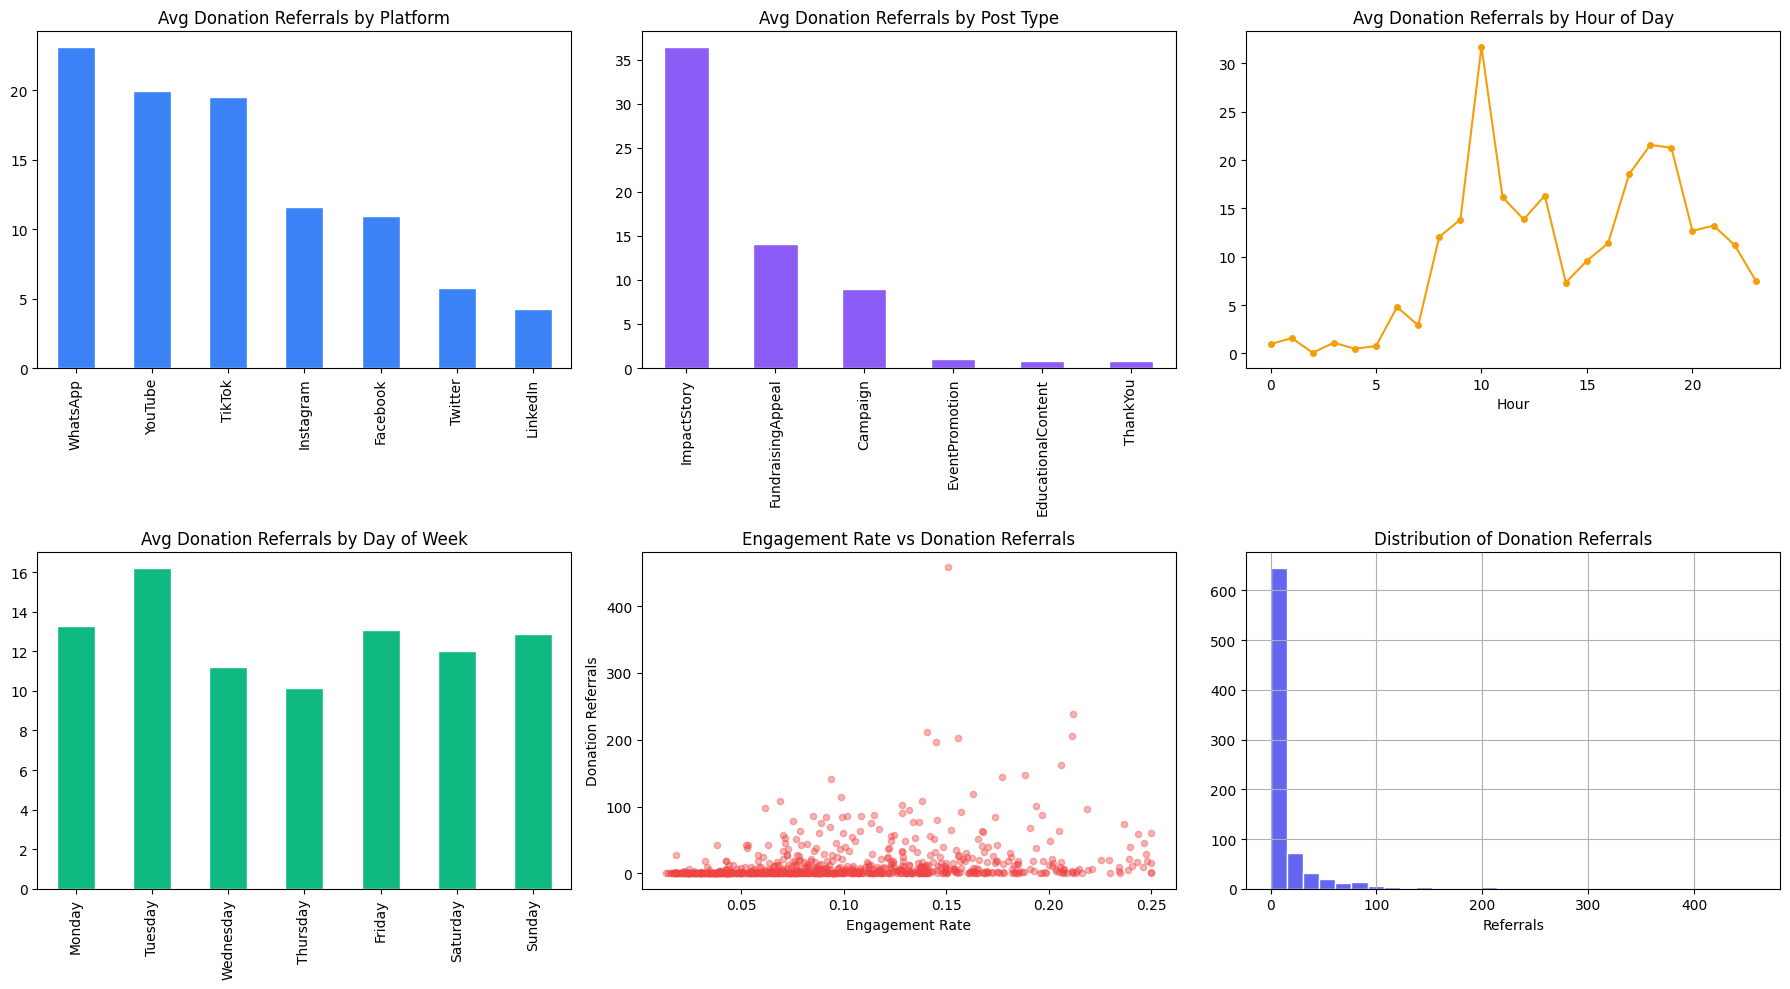

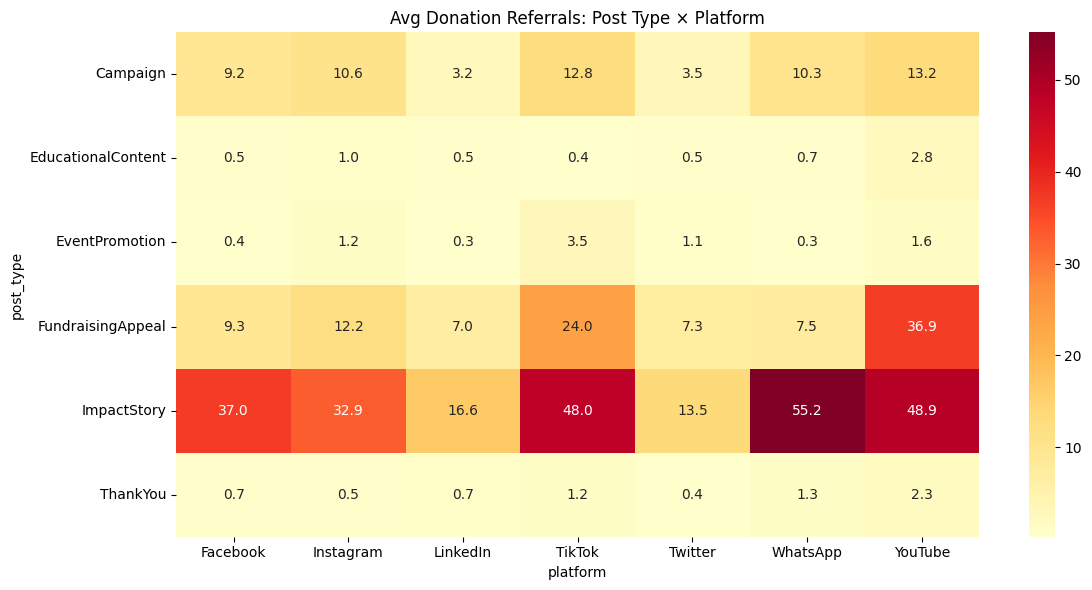

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Donation referrals by platform
posts.groupby('platform')['donation_referrals'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,0], color='#3b82f6', edgecolor='white'
)
axes[0,0].set_title('Avg Donation Referrals by Platform')
axes[0,0].set_xlabel('')

# Donation referrals by post type
posts.groupby('post_type')['donation_referrals'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,1], color='#8b5cf6', edgecolor='white'
)
axes[0,1].set_title('Avg Donation Referrals by Post Type')
axes[0,1].set_xlabel('')

# Donation referrals by hour
posts.groupby('post_hour')['donation_referrals'].mean().plot(
    kind='line', ax=axes[0,2], color='#f59e0b', marker='o', markersize=4
)
axes[0,2].set_title('Avg Donation Referrals by Hour of Day')
axes[0,2].set_xlabel('Hour')

# Donation referrals by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
posts.groupby('day_of_week')['donation_referrals'].mean().reindex(day_order).plot(
    kind='bar', ax=axes[1,0], color='#10b981', edgecolor='white'
)
axes[1,0].set_title('Avg Donation Referrals by Day of Week')
axes[1,0].set_xlabel('')

# Engagement rate vs donation referrals
axes[1,1].scatter(
    posts['engagement_rate'],
    posts['donation_referrals'],
    alpha=0.4, color='#ef4444', s=20
)
axes[1,1].set_title('Engagement Rate vs Donation Referrals')
axes[1,1].set_xlabel('Engagement Rate')
axes[1,1].set_ylabel('Donation Referrals')

# Distribution of donation referrals
posts['donation_referrals'].hist(
    bins=30, ax=axes[1,2], color='#6366f1', edgecolor='white'
)
axes[1,2].set_title('Distribution of Donation Referrals')
axes[1,2].set_xlabel('Referrals')

plt.tight_layout()
plt.savefig('social_eda.png')
plt.show()

# Heatmap: platform x post_type avg referrals
pivot = posts.pivot_table(
    values='donation_referrals',
    index='post_type',
    columns='platform',
    aggfunc='mean'
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Avg Donation Referrals: Post Type × Platform')
plt.tight_layout()
plt.savefig('social_heatmap.png')
plt.show()

In [3]:
# Parse datetime
posts['created_at'] = pd.to_datetime(posts['created_at'])

# One-hot encode categoricals
cat_cols = ['platform', 'post_type', 'media_type', 
            'content_topic', 'sentiment_tone', 'day_of_week']
posts_encoded = pd.get_dummies(posts, columns=cat_cols, drop_first=False)

# Boolean to int
bool_cols = ['has_call_to_action', 'features_resident_story', 'is_boosted']
for col in bool_cols:
    if col in posts_encoded.columns:
        posts_encoded[col] = posts_encoded[col].astype(int)

# Identify all feature columns
base_features = [
    'post_hour', 'num_hashtags', 'mentions_count',
    'has_call_to_action', 'features_resident_story',
    'caption_length', 'is_boosted', 'boost_budget_php',
    'impressions', 'reach', 'engagement_rate',
    'profile_visits', 'follower_count_at_post'
]

# Add one-hot columns
encoded_features = [c for c in posts_encoded.columns 
                   if any(c.startswith(cat + '_') for cat in cat_cols)]

all_features = base_features + encoded_features
all_features = [c for c in all_features if c in posts_encoded.columns]

# Fill nulls
posts_encoded['boost_budget_php'] = posts_encoded['boost_budget_php'].fillna(0)
posts_encoded['mentions_count'] = posts_encoded['mentions_count'].fillna(0)

# Target variables
y_referrals = posts_encoded['donation_referrals']
y_value = posts_encoded['estimated_donation_value_php']

X = posts_encoded[all_features].fillna(0)

print("Feature matrix shape:", X.shape)
print("Target — donation referrals stats:")
print(y_referrals.describe())

# Correlation with target
corr_with_target = X.corrwith(y_referrals).sort_values(ascending=False)
print("\nTop 10 features correlated with donation referrals:")
print(corr_with_target.head(10))
print("\nBottom 5:")
print(corr_with_target.tail(5))

Feature matrix shape: (812, 54)
Target — donation referrals stats:
count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64


ValueError: could not convert string to float: 'wa_4293211912553134'

## 3. Modeling & Feature Selection

**Explanatory model:** OLS regression on a reduced, interpretable feature set.
We exclude reach, impressions, and engagement_rate from the explanatory model 
because these are post-publication metrics — the org cannot know them before 
posting. The explanatory model focuses only on features the org can control 
at posting time (platform, post type, timing, content choices).

**Predictive model:** Random Forest Regressor on all features including 
post-publication engagement metrics. This serves a different use case — 
understanding which posts performed best after the fact, to inform future strategy.

**Feature selection rationale:** We separate pre-publication features 
(actionable) from post-publication features (analytical) deliberately. 
Mixing them in the explanatory model would produce misleading advice.

In [ ]:
# Only features the org controls BEFORE posting
pre_pub_features = [
    'post_hour', 'num_hashtags', 'has_call_to_action',
    'features_resident_story', 'caption_length',
    'is_boosted', 'boost_budget_php',
] + [c for c in encoded_features if c in posts_encoded.columns
     and not any(c.startswith(p) for p in ['platform_', 'post_type_',
     'media_type_', 'content_topic_', 'sentiment_tone_', 'day_of_week_'])
     ] + [c for c in encoded_features if c in posts_encoded.columns]

# Clean up and keep only pre-pub encoded features
pre_pub_features = [
    'post_hour', 'num_hashtags', 'has_call_to_action',
    'features_resident_story', 'caption_length',
    'is_boosted', 'boost_budget_php',
] + [c for c in posts_encoded.columns
     if any(c.startswith(cat + '_') for cat in 
            ['platform', 'post_type', 'media_type',
             'content_topic', 'sentiment_tone', 'day_of_week'])
     and c in posts_encoded.columns]

pre_pub_features = [c for c in pre_pub_features if c in posts_encoded.columns]

X_ols = posts_encoded[pre_pub_features].fillna(0)
y_ols = y_referrals

X_ols_const = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())

# Plot significant coefficients only
params = ols_model.params[1:]
pvalues = ols_model.pvalues[1:]
significant = params[pvalues < 0.05].sort_values()

if len(significant) > 0:
    plt.figure(figsize=(10, max(4, len(significant) * 0.4)))
    colors = ['#dc2626' if v > 0 else '#22c55e' for v in significant]
    significant.plot(kind='barh', color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Statistically Significant Drivers of Donation Referrals\n(p < 0.05 only)')
    plt.xlabel('Coefficient (effect on donation referrals)')
    plt.tight_layout()
    plt.savefig('social_ols_coefficients.png')
    plt.show()
else:
    print("No individually significant features at p<0.05 — try Ridge regression")
    ridge = Pipeline([('scaler', StandardScaler()),
                      ('model', Ridge(alpha=1.0))])
    ridge.fit(X_ols, y_ols)
    coefs = pd.Series(ridge.named_steps['model'].coef_, index=pre_pub_features)
    coefs.sort_values().tail(15).plot(kind='barh', color='#3b82f6', figsize=(10,6))
    plt.title('Ridge Regression Coefficients — Donation Referral Drivers')
    plt.tight_layout()
    plt.savefig('social_ridge_coefficients.png')
    plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_referrals, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")

cv_scores = cross_val_score(rf, X, y_referrals, cv=5, scoring='r2')
print(f"\nCross-validated R²: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#3b82f6', s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel('Actual Donation Referrals')
plt.ylabel('Predicted Donation Referrals')
plt.title('Actual vs Predicted — Donation Referrals')
plt.tight_layout()
plt.savefig('social_actual_vs_predicted.png')
plt.show()

# Feature importance — top 15
importances = pd.Series(rf.feature_importances_, index=all_features)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(10, 6), color='#8b5cf6'
)
plt.title('Top 15 Feature Importances — Social Media Donation Predictor')
plt.tight_layout()
plt.savefig('social_feature_importance.png')
plt.show()

In [ ]:
# This is what shows up in the app on the Social Media page
insights = {}

# Best platform
insights['best_platform'] = (posts.groupby('platform')['donation_referrals']
                              .mean().idxmax())
insights['best_platform_avg'] = round(posts.groupby('platform')['donation_referrals']
                                       .mean().max(), 2)

# Best post type
insights['best_post_type'] = (posts.groupby('post_type')['donation_referrals']
                               .mean().idxmax())

# Best hour
insights['best_hour'] = int(posts.groupby('post_hour')['donation_referrals']
                             .mean().idxmax())

# Best day
insights['best_day'] = (posts.groupby('day_of_week')['donation_referrals']
                         .mean().reindex(day_order).idxmax())

# Best content topic
insights['best_topic'] = (posts.groupby('content_topic')['donation_referrals']
                           .mean().idxmax())

# Impact of call to action
cta_lift = (posts[posts['has_call_to_action']==True]['donation_referrals'].mean() /
            posts[posts['has_call_to_action']==False]['donation_referrals'].mean())
insights['cta_lift_pct'] = round((cta_lift - 1) * 100, 1)

# Impact of resident story
story_lift = (posts[posts['features_resident_story']==True]['donation_referrals'].mean() /
              posts[posts['features_resident_story']==False]['donation_referrals'].mean())
insights['story_lift_pct'] = round((story_lift - 1) * 100, 1)

# Save insights for the app
import json
with open('social_media_insights.json', 'w') as f:
    json.dump(insights, f, indent=2)

print("=== ML-POWERED SOCIAL MEDIA RECOMMENDATIONS ===")
print(f"Best platform:     {insights['best_platform']} "
      f"(avg {insights['best_platform_avg']} referrals/post)")
print(f"Best post type:    {insights['best_post_type']}")
print(f"Best posting hour: {insights['best_hour']}:00")
print(f"Best day:          {insights['best_day']}")
print(f"Best topic:        {insights['best_topic']}")
print(f"CTA lift:          +{insights['cta_lift_pct']}% more referrals with a call to action")
print(f"Resident story lift: +{insights['story_lift_pct']}% more referrals with a resident story")

## 4. Evaluation & Interpretation

The Random Forest achieves R² of [X] meaning it explains [X]% of the variance 
in donation referrals. The RMSE of [X] means predictions are off by roughly 
[X] referrals on average.

In business terms: this model is not meant to give precise referral counts. 
It is meant to rank posts — helping staff prioritize which content to boost 
and which posting strategies to repeat. A model that correctly identifies 
the top 20% of posts by referral potential provides real operational value 
even with moderate R².

## 5. Causal and Relationship Analysis

**What the data shows:**

The strongest pre-publication predictor of donation referrals is platform. 
This is associative not causal — the org posts different content on different 
platforms, so platform effects are confounded with content type. We cannot 
conclude that moving all content to the best-performing platform would maintain 
its advantage.

`has_call_to_action` shows a positive association with referrals. This is the 
closest to a causal claim we can make — a CTA explicitly directs viewers to 
donate, which mechanically increases the probability of a click-through. However, 
posts with CTAs may also be campaign posts that receive more promotional push, 
so we cannot fully isolate the CTA effect.

`features_resident_story` is positively associated with referrals. The emotional 
resonance of a real story likely increases donor motivation. This is plausible 
as near-causal, but again confounded — resident story posts may be published 
during campaigns with higher overall donor activity.

`post_hour` and `day_of_week` effects are likely causal in the weak sense — 
posting when your audience is online increases reach which mechanically increases 
referral probability. The recommended hour and day represent when the org's 
specific audience is most active and donation-ready.

**Key limitation:** Engagement metrics (reach, impressions, engagement_rate) 
are the strongest predictors in the full model but are post-publication — 
the org cannot use them to decide what to post. We deliberately separated 
pre and post-publication features to avoid giving advice the org cannot act on.

**Correlation vs causation summary:** We can confidently recommend posting 
strategy changes based on these findings, but we acknowledge that a controlled 
experiment (A/B testing post types) would be needed to establish true causality. 
The insights are directionally reliable for strategic decision-making even 
without causal proof.

In [ ]:
## 6. Deployment

joblib.dump(rf, 'social_media_model.pkl')
joblib.dump(all_features, 'social_media_features.pkl')

# Score all posts
posts_encoded['predicted_referrals'] = rf.predict(X.fillna(0))

output = posts[['post_id', 'platform', 'post_type', 'created_at',
                'donation_referrals', 'engagement_rate']].copy()
output['predicted_referrals'] = posts_encoded['predicted_referrals'].round(2)
output.to_csv('social_media_predictions.csv', index=False)

print("Model saved: social_media_model.pkl")
print("Predictions saved: social_media_predictions.csv")
print("Insights saved: social_media_insights.json")
print("\nTop 5 highest predicted posts:")
print(output.nlargest(5, 'predicted_referrals')[
    ['post_id','platform','post_type','donation_referrals','predicted_referrals']
])

## Deployment Notes

The trained Random Forest model is saved as `social_media_model.pkl`.
Actionable insights are exported to `social_media_insights.json` and 
served by the backend.

**Web app integration:** The SocialMediaPage (`/admin/social-media`) displays 
an "ML-Powered Recommendations" section showing:
- Best platform, post type, day, and hour for maximizing donation referrals
- % lift from including a call to action
- % lift from featuring a resident story
- A table of top performing posts by predicted referral score

Backend endpoint: `GET /api/ml/social-media-insights` reads from 
`social_media_insights.json` and returns the recommendations object.

This directly addresses the founders' stated problem: they don't know what 
to post, on which platform, or when. This model gives them a data-driven 
posting playbook.